<a href="https://colab.research.google.com/github/hainguyen31251026260-hue/AI-UEH/blob/main/CNNipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Dropout,Flatten,Dense
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
from keras.datasets import cifar10
(x_train,y_train), (x_test,y_test)=cifar10.load_data()
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Dropout,Flatten,Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
train_dir = "/content/drive/MyDrive/AI/60 ẢNH/60 ẢNH"
validation_dir = "/content/drive/MyDrive/AI/60 ẢNH/60 ẢNH"
img_width,img_height=128,128
batch_size=32
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully.")
validation_datagen = ImageDataGenerator(rescale=1.0/255)
train_dir = "/content/drive/MyDrive/AI/60 ẢNH/60 ẢNH"
validation_dir = "/content/drive/MyDrive/AI/60 ẢNH/60 ẢNH"

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

print(f"Số lượng lớp thực tế tìm thấy: {len(train_generator.class_indices)}")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5), # Reduce overfitting
    Dense(6, activation="softmax") # 5...
])
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential

# Lấy số lượng lớp thực tế từ generator
num_classes = len(train_generator.class_indices)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.
Found 576 images belonging to 24 classes.
Found 576 images belonging to 24 classes.
Số lượng lớp thực tế tìm thấy: 24
Found 576 images belonging to 24 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 109s 6s/step - accuracy: 0.0938 - loss: 3.0612 - val_accuracy: 0.0903 - val_loss: 2.9585
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 117s 5s/step - accuracy: 0.1024 - loss: 2.9620 - val_accuracy: 0.2049 - val_loss: 2.7517
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 88s 5s/step - accuracy: 0.1406 - loss: 2.8167 - val_accuracy: 0.1910 - val_loss: 2.6457
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 0.1701 - loss: 2.7010 - val_accuracy: 0.2674 - val_loss: 2.4314
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 90s 5s/step - accuracy: 0.2240 - loss: 2.5854 - val_accuracy: 0.2882 - val_loss: 2.3319
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 115s 7s/step - accuracy: 0.2170 - loss: 2.5155 - val_accuracy: 0.4201 - val_loss: 2.0613
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 90s 5s/step - accuracy: 0.2830 - loss: 2.3931 - val_accuracy: 0.4653 - val_loss: 1.9312
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 72s 4s/step - accuracy: 0.3160 - loss: 2.3541 - val_accuracy: 0.4948 - val_lo

KeyboardInterrupt: 

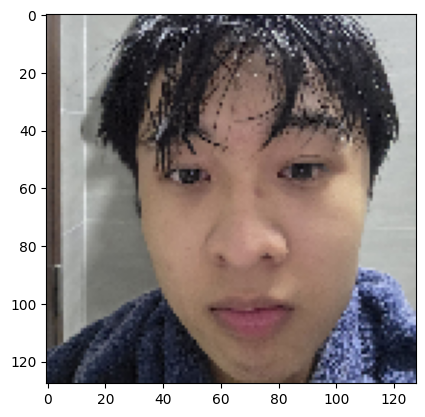

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Người tiên đoán: NGUYEN HUU TOAN


In [ ]:
# Tải và tiền xử lý ảnh kiểm tra
from keras.utils import load_img
import numpy as np
path = "/content/20260522_001007.jpg"

# Tiên đoán loại s
img = load_img(path, target_size=(128, 128))
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 128, 128, 3)
prediction=np.argmax(model.predict(img))

# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")

In [ ]:
model.save('faceid_model.h5')
print('đã lưu')

đã lưu
